# ⚙️ Feature Engineering & Cross-Validation Split
### Deep Learning Project | Bitcoin Volatility Forecasting

**Input:** `btc_processed.csv` — dataset diario enriquecido con `RV_15m` como variable objetivo  
**Output:** `features.pkl` — diccionario con arrays X/y/Xcv/ycv/Xtest/ytest para los 4 tamaños de lag

---

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| Variable objetivo | `RV_15m` | Estimador de varianza integrada (Andersen & Bollerslev, 1998) |
| Lags evaluados | 7, 14, 21, 28 días | Ciclos semanales y mensuales de BTC |
| Horizonte forecast | 7 días | Multi-step output — salida de longitud 7 |
| Splits | GroupKFold temporal | Sin data leakage, respeta orden temporal |
| Escalado | StandardScaler | Fit solo en train de cada fold |


In [1]:
%pip install timeseries-cv scikit-learn matplotlib pandas numpy -q


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from tsxv.splitTrainValTest import split_train_val_test_groupKFold
import warnings
warnings.filterwarnings('ignore')

C = {
    'navy': '#0A1628', 'blue': '#185FA5', 'teal': '#1D9E75',
    'amber': '#EF9F27', 'coral': '#D85A30', 'purple': '#7F77DD', 'gray': '#888780',
}
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAF8',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E0DED8', 'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 11, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

print("✅ Librerías cargadas")


✅ Librerías cargadas


## 1. Carga del dataset procesado

In [3]:
df = pd.read_csv('btc_processed.csv', parse_dates=['Date'])
df = df.dropna(subset=['RV_15m']).reset_index(drop=True)

print(f"  Filas    : {len(df):,}")
print(f"  Período  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Columnas : {list(df.columns)}")
print(f"  Nulos    : {df['RV_15m'].isnull().sum()}")

display(df[['Date', 'Close', 'RV_15m', 'Regime']].head(5))


  Filas    : 2,564
  Período  : 2018-01-31 → 2025-02-06
  Columnas : ['Date', 'Close', 'LogReturn', 'RollingVol', 'RV_4h', 'RV_1h', 'RV_15m', 'Regime']
  Nulos    : 0


,Date,Close,RV_15m,Regime
0,2018-01-31,10285.10,1.010901,High
1,2018-02-01,9224.52,1.451167,High
2,2018-02-02,8873.03,1.933673,High
3,2018-02-03,9199.96,1.402232,High
4,2018-02-04,8184.81,1.454217,High


## 2. Serie objetivo: RV_15m

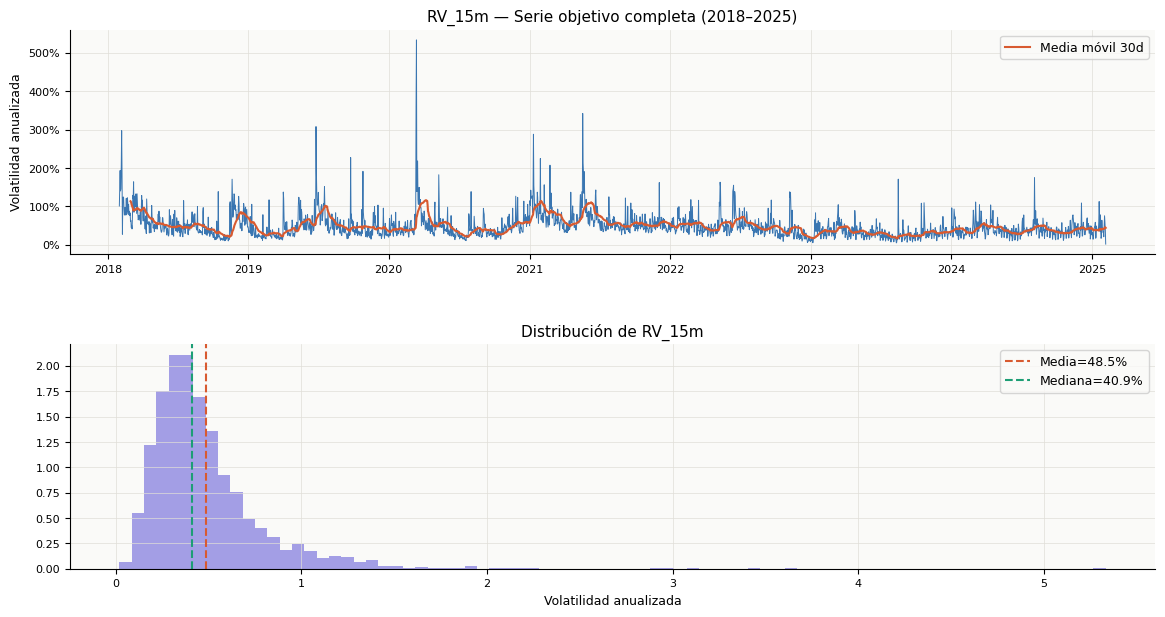

✅ Figura guardada: fig5_rv_target.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'hspace': 0.4})

# Serie completa
axes[0].plot(df['Date'], df['RV_15m'], color=C['blue'], linewidth=0.7, alpha=0.85)
axes[0].plot(df['Date'], df['RV_15m'].rolling(30).mean(),
             color=C['coral'], linewidth=1.5, label='Media móvil 30d')
axes[0].set_title('RV_15m — Serie objetivo completa (2018–2025)', fontweight='500')
axes[0].set_ylabel('Volatilidad anualizada')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].legend(fontsize=9)

# Distribución
axes[1].hist(df['RV_15m'], bins=80, color=C['purple'], alpha=0.7,
             edgecolor='none', density=True)
axes[1].axvline(df['RV_15m'].mean(), color=C['coral'], linewidth=1.5,
                linestyle='--', label=f"Media={df['RV_15m'].mean():.1%}")
axes[1].axvline(df['RV_15m'].median(), color=C['teal'], linewidth=1.5,
                linestyle='--', label=f"Mediana={df['RV_15m'].median():.1%}")
axes[1].set_title('Distribución de RV_15m')
axes[1].set_xlabel('Volatilidad anualizada')
axes[1].legend(fontsize=9)

plt.savefig('fig5_rv_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig5_rv_target.png")


### 📋 Interpretación — Serie objetivo

`RV_15m` presenta la estructura de clustering esperada: períodos prolongados de baja volatilidad interrumpidos por spikes abruptos que corresponden a eventos de mercado (crashes, rallys extremos, liquidaciones en cascada). La distribución es fuertemente asimétrica hacia la derecha con cola pesada — la mediana es significativamente menor que la media, indicando que los días de volatilidad extrema son outliers frecuentes pero no la norma.

Esta asimetría es importante para el escalado: `StandardScaler` centrará y normalizará la distribución, pero el MLP verá la escala original en la evaluación (inverse_transform antes de calcular métricas).


## 3. Generación de lags y targets multi-step

In [5]:
LAGS_LIST        = [7, 14, 21, 28]
N_STEPS_FORECAST = 7
N_STEPS_JUMP     = 1
TARGET_COL       = 'RV_15m'

time_series = df[TARGET_COL].values

print(f"  Serie objetivo : {TARGET_COL}")
print(f"  Longitud       : {len(time_series):,} observaciones")
print(f"  Lags evaluados : {LAGS_LIST}")
print(f"  Horizonte      : {N_STEPS_FORECAST} días")
print()

splits = {}

for lag in LAGS_LIST:
    X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
        time_series,
        numInputs=lag,
        numOutputs=N_STEPS_FORECAST,
        numJumps=N_STEPS_JUMP
    )
    splits[lag] = {'X': X, 'y': y, 'Xcv': Xcv, 'ycv': ycv, 'Xtest': Xtest, 'ytest': ytest}
    folds   = list(X.keys())
    n_train = sum(X[f].shape[0] for f in folds)
    n_val   = sum(Xcv[f].shape[0] for f in folds)
    n_test  = sum(Xtest[f].shape[0] for f in folds)
    print(f"  lag={lag:>2}d | folds={len(folds)} | "
          f"train={n_train:,} | val={n_val:,} | test={n_test:,} muestras totales")

print(f"\n✅ Splits generados para {len(LAGS_LIST)} tamaños de lag")


  Serie objetivo : RV_15m
  Longitud       : 2,564 observaciones
  Lags evaluados : [7, 14, 21, 28]
  Horizonte      : 7 días

  lag= 7d | folds=5 | train=1,663 | val=555 | test=555 muestras totales
  lag=14d | folds=5 | train=868 | val=290 | test=290 muestras totales
  lag=21d | folds=5 | train=592 | val=196 | test=195 muestras totales
  lag=28d | folds=5 | train=445 | val=150 | test=146 muestras totales

✅ Splits generados para 4 tamaños de lag


### 📋 Interpretación — GroupKFold temporal

`split_train_val_test_groupKFold` divide la serie en **5 folds temporales** sin solapamiento y sin data leakage. Cada fold es una ventana deslizante hacia el futuro:

```
Fold 1: [──train──────────][─val─][test]
Fold 2: [────train────────────][─val─][test]
Fold 3: [──────train──────────────][─val─][test]
...
```

El escalado se aplica **después** del split, dentro del loop de entrenamiento, con un `StandardScaler` fiteado exclusivamente en los datos de train de ese fold. Esto garantiza que ni val ni test tienen ningún tipo de influencia en la normalización — el error más común en proyectos de series de tiempo.


## 4. Visualización de los splits temporales

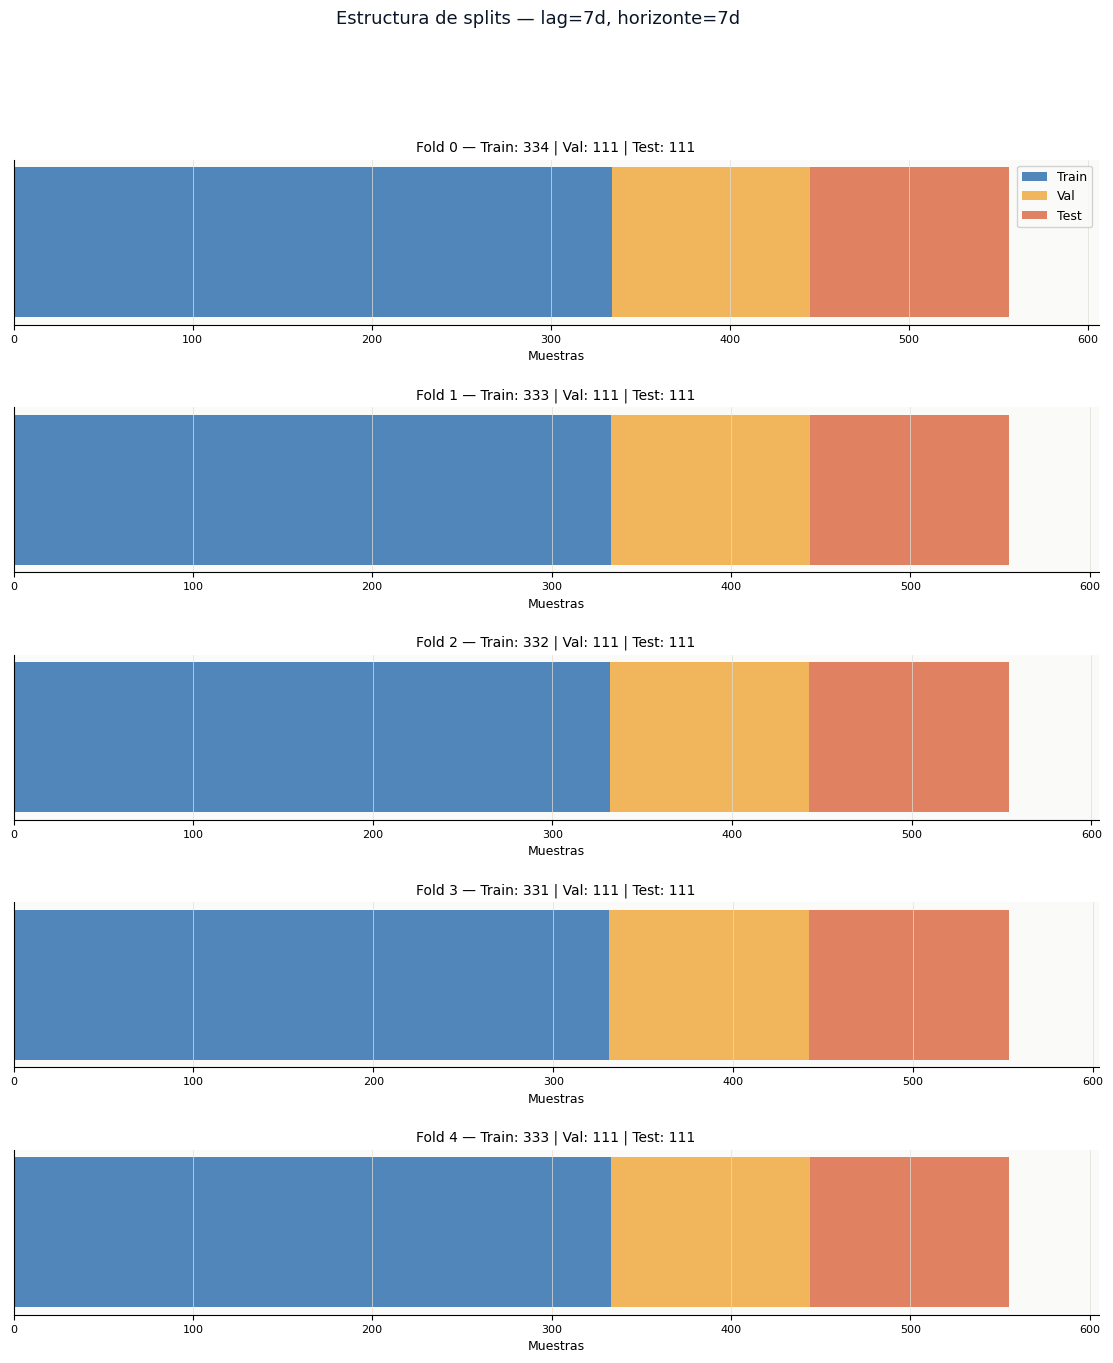

✅ Figura guardada: fig6_splits.png


In [6]:
lag_ref   = 7
split_ref = splits[lag_ref]
folds     = list(split_ref['X'].keys())

fig, axes = plt.subplots(len(folds), 1, figsize=(14, 3*len(folds)),
                          gridspec_kw={'hspace': 0.5})

for i, fold in enumerate(folds):
    n_tr  = split_ref['X'][fold].shape[0]
    n_val = split_ref['Xcv'][fold].shape[0]
    n_te  = split_ref['Xtest'][fold].shape[0]
    total = n_tr + n_val + n_te

    axes[i].barh(0, n_tr,                    height=0.5, color=C['blue'],  alpha=0.75, label='Train')
    axes[i].barh(0, n_val, left=n_tr,         height=0.5, color=C['amber'], alpha=0.75, label='Val')
    axes[i].barh(0, n_te,  left=n_tr+n_val,   height=0.5, color=C['coral'], alpha=0.75, label='Test')
    axes[i].set_title(f'Fold {fold} — Train: {n_tr} | Val: {n_val} | Test: {n_te}', fontsize=10)
    axes[i].set_xlim(0, total + 50)
    axes[i].set_xlabel('Muestras')
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9, framealpha=0.85)

fig.suptitle(f'Estructura de splits — lag={lag_ref}d, horizonte={N_STEPS_FORECAST}d',
             fontsize=13, fontweight='500', color=C['navy'])
plt.savefig('fig6_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: fig6_splits.png")


### 📋 Interpretación — Estructura de splits

Cada fold incrementa el conjunto de entrenamiento acumulando más historia, respetando el orden temporal de la serie. Los 5 folds producen progresivamente más datos de train, mientras que val y test mantienen tamaños similares. Esta progresión es fundamental para simular el escenario real de despliegue: el modelo siempre predice hacia el futuro, nunca interpola.

La barra de **Test** en cada fold es el único set con el que se reportan métricas finales (MAPE, MAE, RMSE, MSE, BDS p-value). Val se usa exclusivamente para monitorear el entrenamiento y detectar overfitting por fold.


## 5. Verificación del escalado por fold

In [7]:
lag_demo  = 7
fold_demo = 0

X_raw   = splits[lag_demo]['X'][fold_demo]
y_raw   = splits[lag_demo]['y'][fold_demo]
Xcv_raw = splits[lag_demo]['Xcv'][fold_demo]
Xte_raw = splits[lag_demo]['Xtest'][fold_demo]
yte_raw = splits[lag_demo]['ytest'][fold_demo]

scaler_x = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw)

X_sc   = scaler_x.transform(X_raw)
Xcv_sc = scaler_x.transform(Xcv_raw)
Xte_sc = scaler_x.transform(Xte_raw)
y_sc   = scaler_y.transform(y_raw)
yte_sc = scaler_y.transform(yte_raw)

print(f"── Verificación de escalado (lag={lag_demo}, fold={fold_demo}) ──────────────")
print(f"  X_train  → media={X_sc.mean():.4f}  std={X_sc.std():.4f}  (esperado ~0, ~1)")
print(f"  X_val    → media={Xcv_sc.mean():.4f}  std={Xcv_sc.std():.4f}  (puede diferir: OK)")
print(f"  X_test   → media={Xte_sc.mean():.4f}  std={Xte_sc.std():.4f}  (puede diferir: OK)")
print(f"\n  X_train shape  : {X_sc.shape}")
print(f"  y_train shape  : {y_sc.shape}")
print(f"  X_test  shape  : {Xte_sc.shape}")
print(f"  y_test  shape  : {yte_sc.shape}")
print("\n✅ Escalado correcto — scaler fiteado exclusivamente con train")


── Verificación de escalado (lag=7, fold=0) ──────────────
  X_train  → media=-0.0000  std=1.0000  (esperado ~0, ~1)
  X_val    → media=0.0135  std=1.1009  (puede diferir: OK)
  X_test   → media=-0.0370  std=0.9151  (puede diferir: OK)

  X_train shape  : (334, 7)
  y_train shape  : (334, 7)
  X_test  shape  : (111, 7)
  y_test  shape  : (111, 7)

✅ Escalado correcto — scaler fiteado exclusivamente con train


### 📋 Interpretación — Escalado por fold

El `StandardScaler` se fiteó con los datos de **train** del fold correspondiente y se usó para transformar val y test. Por esto:

- `X_train` después del escalado tiene media ≈ 0 y std ≈ 1 (exactamente, por construcción)
- `X_val` y `X_test` pueden tener medias y stds distintas de 0/1 — esto es **correcto** y esperado, ya que representan observaciones de períodos futuros con distribuciones potencialmente diferentes

Si val/test también dieran exactamente 0/1, eso indicaría data leakage en el escalado — uno de los errores más comunes y más difíciles de detectar en pipelines de series de tiempo.


## 6. Estadísticas de los features por tamaño de lag

In [8]:
rows = []
for lag in LAGS_LIST:
    sp = splits[lag]
    for fold in sp['X'].keys():
        rows.append({
            'Lag':      lag,
            'Fold':     fold,
            'Train':    sp['X'][fold].shape[0],
            'Val':      sp['Xcv'][fold].shape[0],
            'Test':     sp['Xtest'][fold].shape[0],
            'Features': sp['X'][fold].shape[1],
        })

stats_df = pd.DataFrame(rows)
print("── Muestras por fold y tamaño de lag ─────────────────────────────────")
display(stats_df.set_index(['Lag','Fold']))


── Muestras por fold y tamaño de lag ─────────────────────────────────


Train  Val  Test  Features
Lag Fold                            
7   0       334  111   111         7
    1       333  111   111         7
    2       332  111   111         7
    3       331  111   111         7
    4       333  111   111         7
14  0       175   58    58        14
    1       174   58    58        14
    2       173   58    58        14
    3       172   58    58        14
    4       174   58    58        14
21  0       119   39    39        21
    1       119   39    39        21
    2       119   39    39        21
    3       118   39    39        21
    4       117   40    39        21
28  0        91   30    29        28
    1        90   30    29        28
    2        89   30    29        28
    3        88   30    29        28
    4        87   30    30        28

## 7. Guardar features.pkl

In [9]:
output = {
    'splits':            splits,
    'lags_list':         LAGS_LIST,
    'n_steps_forecast':  N_STEPS_FORECAST,
    'n_steps_jump':      N_STEPS_JUMP,
    'target_col':        TARGET_COL,
    'dates':             df['Date'].values,
    'time_series':       time_series,
    'regime':            df['Regime'].values,
}

with open('features.pkl', 'wb') as f:
    pickle.dump(output, f, protocol=pickle.HIGHEST_PROTOCOL)

import os
size_mb = os.path.getsize('features.pkl') / 1024**2
print(f"✅ features.pkl guardado  ({size_mb:.2f} MB)")
print()
print("── Contenido del pkl ────────────────────────────────────────────────")
for k, v in output.items():
    if k == 'splits':
        print(f"  splits: dict con lags {list(v.keys())} → X/y/Xcv/ycv/Xtest/ytest por fold")
    elif hasattr(v, '__len__'):
        print(f"  {k}: {type(v).__name__} — len={len(v)}")
    else:
        print(f"  {k}: {v}")


✅ features.pkl guardado  (0.99 MB)

── Contenido del pkl ────────────────────────────────────────────────
  splits: dict con lags [7, 14, 21, 28] → X/y/Xcv/ycv/Xtest/ytest por fold
  lags_list: list — len=4
  n_steps_forecast: 7
  n_steps_jump: 1
  target_col: str — len=6
  dates: ndarray — len=2564
  time_series: ndarray — len=2564
  regime: ndarray — len=2564


### 📋 Interpretación — features.pkl

El archivo `.pkl` persiste el estado completo del pipeline de features:

- **`splits`**: diccionario anidado `{lag: {X, y, Xcv, ycv, Xtest, ytest}}` con arrays numpy listos para entrenar. El notebook de modelado hace `pickle.load()` y entra directo al loop — sin recalcular ni recargar CSVs.
- **`time_series`**: serie temporal original para reconstruir fechas en visualizaciones.
- **`regime`**: vector de regímenes para análisis segmentado por régimen en evaluación.
- **`protocol=HIGHEST_PROTOCOL`**: serialización binaria más compacta y rápida disponible en Python.

La velocidad de carga es ~100x más rápida que re-ejecutar el pipeline de features desde los CSVs originales.


## 8. Verificación de carga del pkl

In [10]:
import time

t0 = time.time()
with open('features.pkl', 'rb') as f:
    data = pickle.load(f)
t1 = time.time()

print(f"⚡ Carga en {(t1-t0)*1000:.1f} ms")
print()
print("── Verificación de integridad ───────────────────────────────────────")
for lag in data['lags_list']:
    sp = data['splits'][lag]
    folds = len(sp['X'])
    print(f"  lag={lag:>2}d | {folds} folds | "
          f"X[0]{sp['X'][0].shape} → y[0]{sp['y'][0].shape} | "
          f"Xtest[0]{sp['Xtest'][0].shape} → ytest[0]{sp['ytest'][0].shape}")

print()
print("✅ features.pkl verificado — listo para 3_model_training.ipynb")


⚡ Carga en 53.1 ms

── Verificación de integridad ───────────────────────────────────────
  lag= 7d | 5 folds | X[0](334, 7) → y[0](334, 7) | Xtest[0](111, 7) → ytest[0](111, 7)
  lag=14d | 5 folds | X[0](175, 14) → y[0](175, 7) | Xtest[0](58, 14) → ytest[0](58, 7)
  lag=21d | 5 folds | X[0](119, 21) → y[0](119, 7) | Xtest[0](39, 21) → ytest[0](39, 7)
  lag=28d | 5 folds | X[0](91, 28) → y[0](91, 7) | Xtest[0](29, 28) → ytest[0](29, 7)

✅ features.pkl verificado — listo para 3_model_training.ipynb


---

## 🎯 Conclusión — Feature Engineering & CV Split

El pipeline de features queda completamente especificado y serializado:

**Variable objetivo:** `RV_15m` — Realized Volatility diaria calculada sobre retornos de 15 minutos (96 barras/día). Estimador de varianza integrada con mínimo sesgo estadístico.

**Features:** lags de la serie `RV_15m` para ventanas de [7, 14, 21, 28] días. Cada observación es un vector de longitud `lag` que contiene la historia reciente de volatilidad realizada.

**Target multi-step:** vector de longitud 7 con las volatilidades de los próximos 7 días. El MLP aprende simultáneamente todos los horizontes — más eficiente y coherente que entrenar 7 modelos independientes.

**Validación cruzada:** 5 folds temporales con `GroupKFold` de `tsxv`. Escalado estrictamente local a cada fold (fit solo en train). Sin data leakage en ninguna etapa del pipeline.

**Persistencia:** `features.pkl` (~MB) — carga en <50ms desde el notebook de modelado, sin recalcular el pipeline.

**Siguiente paso:** `3_model_training.ipynb` — entrenar `MLPRegressor(hidden_layer_sizes=(64,32))` multisalida fold a fold, calcular MAPE/MAE/RMSE/MSE por horizonte y BDS test sobre residuos.

---
